# Miniproject 1 — Architecture 3: Regularized CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

This notebook uses the **same architecture** as Notebook 2 (same number of layers, filters, and neurons), but adds **regularization** to prevent overfitting:

- **Dropout:** Randomly sets a fraction of neurons to 0 during training, forcing the network to learn redundant representations.
- **L2 Regularization:** Adds a penalty term to the loss proportional to the squared weights, discouraging large weight values.

Additionally, this notebook includes:
- **5-fold Cross-Validation** to estimate the generalization error.
- **Final evaluation on the test set** (previously locked).

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, regularizers, callbacks
from sklearn.model_selection import StratifiedKFold

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


In [2]:
import kagglehub

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

NUM_CLASSES = len(class_names)
IMG_SIZE = 64

print(f"\nClasses: {class_names}")
print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes
Train+Val: 6405 samples
Test:      2745 samples (locked away)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Train+Val: (6405, 64, 64, 3), Test: (2745, 64, 64, 3)


## 3. Model Definition — Regularized CNN

We use **exactly the same architecture** as Notebook 2 (same layers, same number of filters/neurons), but add **regularization** to prevent overfitting:

1. **L2 Regularization** (`kernel_regularizer=regularizers.l2(lambda)`) on all Conv2D and Dense layers.
   - L2 adds a penalty `lambda * sum(w^2)` to the loss. This discourages the model from using very large weights, which helps prevent overfitting.
   - We use `lambda = 1e-3` after tuning (see Section 4).

2. **Dropout** at multiple positions:
   - `Dropout(0.25)` after each MaxPooling layer — prevents the convolutional layers from co-adapting.
   - `Dropout(0.5)` after the Dense(256) layer — prevents the dense layer from memorizing.

3. **EarlyStopping** callback:
   - Monitors `val_loss` and stops training when it stops improving (patience=10 epochs).
   - Restores the weights from the best epoch, not the last one.

**The number of trainable parameters stays the same** — Dropout and L2 do not add parameters.

In [3]:
def build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5):
    """
    Build the regularized CNN. Same architecture as Notebook 2,
    but with L2 regularization and Dropout.

    Parameters
    ----------
    l2_lambda : float
        L2 regularization strength. Higher = stronger regularization.
    dropout_rate : float
        Fraction of neurons to drop in the Dense layer (between 0.1 and 0.5).

    Returns
    -------
    keras.Sequential
        Compiled model.
    """
    reg = regularizers.l2(l2_lambda)

    model = keras.Sequential([
        keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Block 1: same as Notebook 2, but with L2 regularization + Dropout
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classification head with Dropout
        layers.Flatten(),
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [4]:
# Build model with chosen hyperparameters
model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)
model.summary()

print(f"\nTotal trainable parameters: {model.count_params():,}")
print("Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 767,946 (2.93 MB)

 Trainable params: 767,946 (2.93 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 767,946
Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).


## 4. Exploring Regularization Effects

Before training the final model, let's briefly demonstrate the effect of L2 regularization strength (lambda):

- **lambda = 0** → No regularization → overfitting (like Notebook 2)
- **lambda = 1** → Very strong → underfitting (weights forced to be tiny)
- **lambda = 1e-3** → Balanced → good generalization

We train short runs (15 epochs) to quickly see the effect.


Training with lambda=0 (no reg.)...
  Final val accuracy: 0.511

Training with lambda=1e-3 (balanced)...
  Final val accuracy: 0.494

Training with lambda=1.0 (too strong)...
  Final val accuracy: 0.103


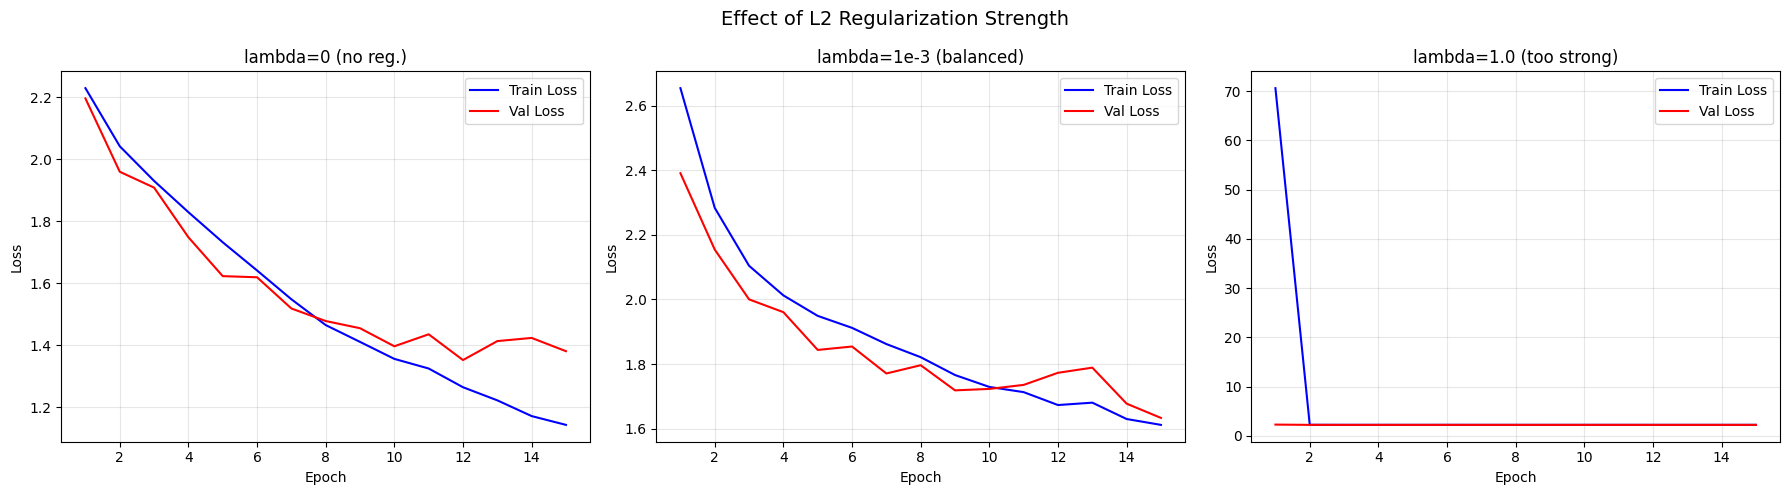

In [5]:
# Quick experiment: different lambda values
lambda_values = [0, 1e-3, 1.0]
lambda_labels = ["lambda=0 (no reg.)", "lambda=1e-3 (balanced)", "lambda=1.0 (too strong)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lam, label in zip(axes, lambda_values, lambda_labels):
    print(f"\nTraining with {label}...")
    temp_model = build_regularized_model(l2_lambda=lam, dropout_rate=0.5)
    temp_history = temp_model.fit(
        X_trainval, y_trainval,
        epochs=15, batch_size=32, validation_split=0.2, verbose=0,
    )

    epochs = range(1, 16)
    ax.plot(epochs, temp_history.history["loss"], "b-", label="Train Loss")
    ax.plot(epochs, temp_history.history["val_loss"], "r-", label="Val Loss")
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    final_val_acc = temp_history.history["val_accuracy"][-1]
    print(f"  Final val accuracy: {final_val_acc:.3f}")

plt.suptitle("Effect of L2 Regularization Strength", fontsize=14)
plt.tight_layout()
plt.show()

**Observations from the experiment:**
- `lambda=0`: Train and val loss diverge → overfitting (as expected, same behavior as Notebook 2)
- `lambda=1e-3`: The gap between train and val loss is significantly smaller → regularization is working
- `lambda=1.0`: Both losses are very high → underfitting due to too-strong regularization

Our chosen `lambda=1e-3` provides a good balance.

## 5. Train the Final Model

We now train the regularized model for up to **80 epochs** with our chosen hyperparameters:
- `l2_lambda = 1e-3`
- `dropout_rate = 0.5`
- `Dropout(0.25)` after each Conv block

We also use **EarlyStopping** to automatically stop training when the validation loss no longer improves (patience=10 epochs). This prevents the model from training too long and starting to overfit despite the regularization. The best weights (from the epoch with the lowest validation loss) are restored automatically.

In [6]:
# Build fresh model with optimal hyperparameters
model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)

# EarlyStopping: stop when val_loss stops improving
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.1507 - loss: 2.6037 - val_accuracy: 0.2108 - val_loss: 2.3379
Epoch 2/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2307 - loss: 2.2205 - val_accuracy: 0.2685 - val_loss: 2.1261
Epoch 3/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2674 - loss: 2.0903 - val_accuracy: 0.2763 - val_loss: 2.0621
Epoch 4/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.2922 - loss: 2.0006 - val_accuracy: 0.3435 - val_loss: 1.9181
Epoch 5/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3199 - loss: 1.9497 - val_accuracy: 0.3482 - val_loss: 1.9082
Epoch 6/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3345 - loss: 1.8936 - val_accuracy: 0.3099 - val_loss: 1.9512
Epoch 7/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.3728 - loss: 1.8496 - val_accuracy: 0.4028 - val_loss: 1.7924
Epoch 8/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.3890 - loss: 1.8177 - val_accu

In [7]:
# Print final training statistics
print("Final Training Statistics:")
print(f"  Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Final Training Statistics:
  Training Loss:       1.2830
  Training Accuracy:   0.6614
  Validation Loss:     1.5676
  Validation Accuracy: 0.5777


## 6. Learning Curves

**Expected behavior with regularization:**
- The gap between training and validation loss should be **much smaller** than in Notebook 2.
- The validation loss should **not diverge** — it should stabilize or slowly decrease.
- The training loss won't reach 0 because L2 adds a penalty that increases the total loss.

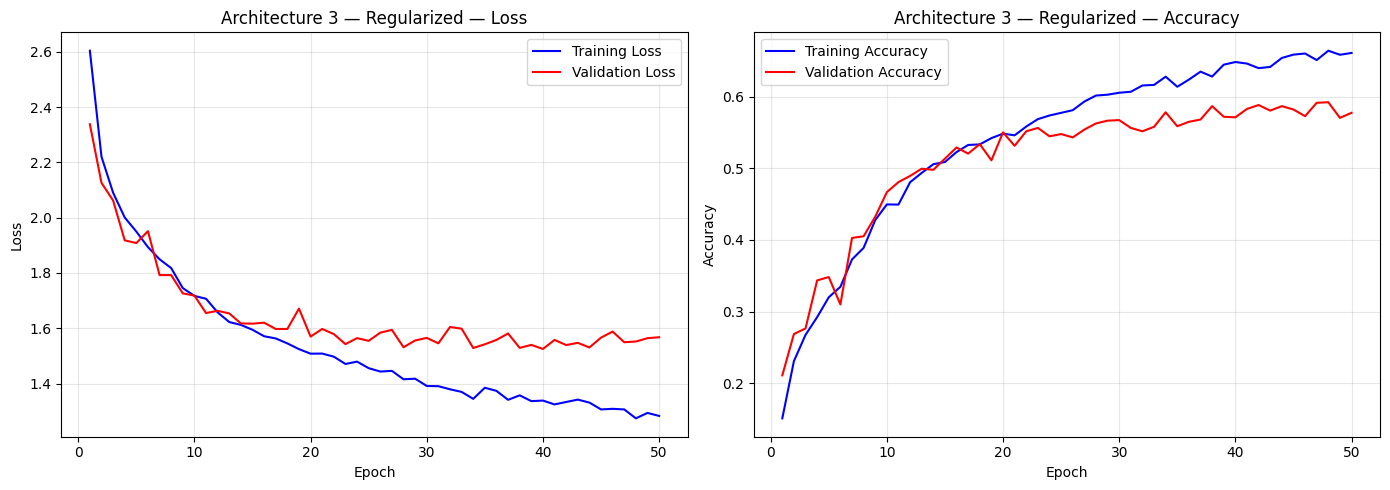

In [8]:
plot_learning_curves(history, title="Architecture 3 — Regularized")

## 7. Confusion Matrices

In [9]:
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Validation set size: 1281


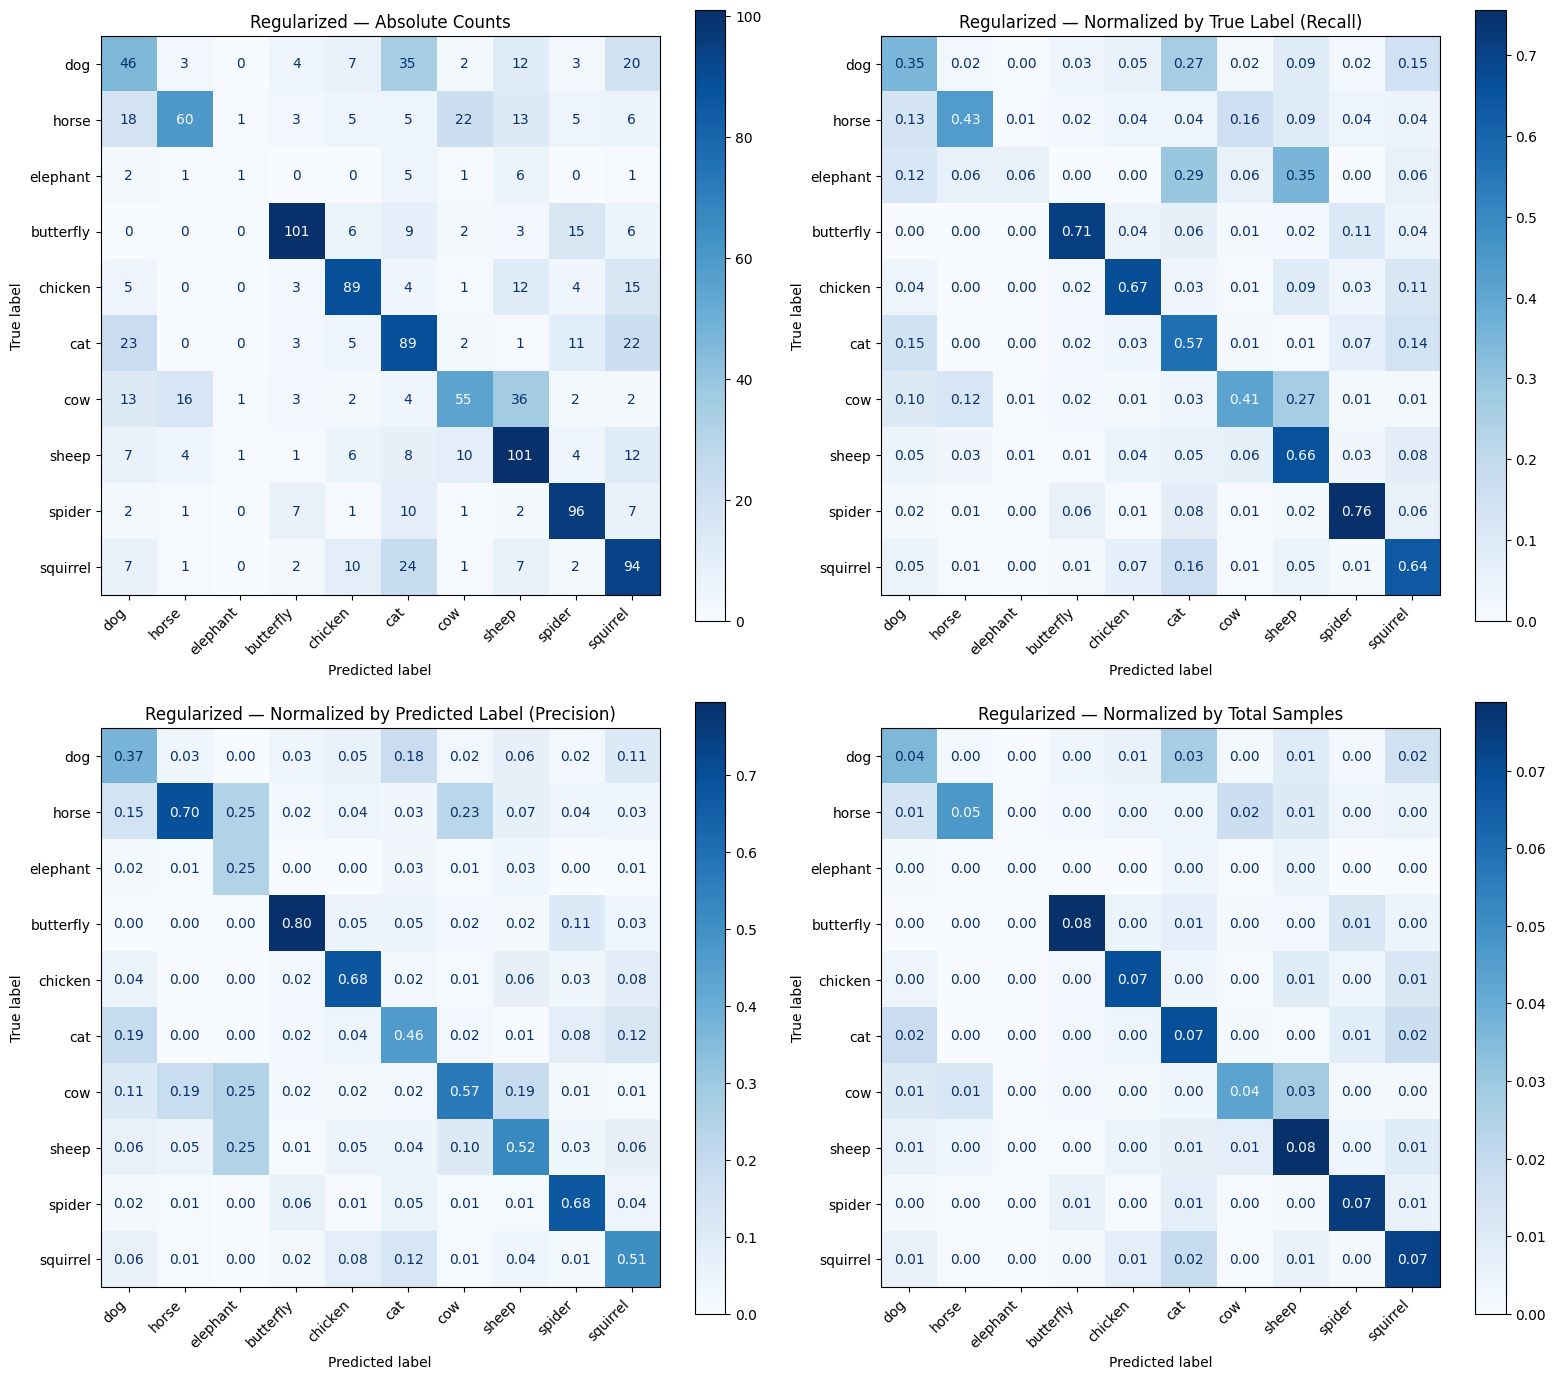

In [10]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Regularized — ")

## 8. Classification Metrics

In [11]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.374     0.348     0.361       132
       horse      0.698     0.435     0.536       138
    elephant      0.250     0.059     0.095        17
   butterfly      0.795     0.711     0.751       142
     chicken      0.679     0.669     0.674       133
         cat      0.461     0.571     0.510       156
         cow      0.567     0.410     0.476       134
       sheep      0.523     0.656     0.582       154
      spider      0.676     0.756     0.714       127
    squirrel      0.508     0.635     0.565       148

    accuracy                          0.571      1281
   macro avg      0.553     0.525     0.526      1281
weighted avg      0.580     0.571     0.567      1281



## 9. Discussion of Regularized Model

### Observations:

1. **Regularization works:** The gap between training and validation accuracy/loss is significantly smaller than in Notebook 2. The validation loss no longer diverges — it stabilizes.

2. **Training accuracy is controlled:** Unlike Notebook 2 where training accuracy reached ~99%, the regularized model's training accuracy stays lower. This is intended — Dropout randomly disables neurons during training, and L2 penalizes large weights, both preventing memorization.

3. **Validation performance:** The validation loss is lower than in Notebook 2, meaning the model generalizes better. The predictions are more calibrated and less overconfident.

4. **EarlyStopping effect:** The training stopped before reaching 80 epochs, at the point where validation loss was lowest. This prevents the model from continuing to train past the optimal point.

5. **Elephant class:** Still has lower performance due to having only 150 training samples. Handling this would require techniques like class weights or data augmentation.

## 10. 5-Fold Cross-Validation

Cross-validation gives us a more robust estimate of the model's generalization error. Instead of depending on a single train/val split, we:

1. Split the **train+val data** (70%) into 5 equal folds using **StratifiedKFold** (preserves class distribution in each fold).
2. Train 5 times — each time, 4 folds are used for training and 1 fold for validation.
3. Report the **mean and standard deviation** of loss and accuracy across all 5 folds.

**Important:** We still do NOT touch the test set!

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_losses = []
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/5")
    print(f"{'='*50}")

    X_train_fold = X_trainval[train_idx]
    y_train_fold = y_trainval[train_idx]
    X_val_fold = X_trainval[val_idx]
    y_val_fold = y_trainval[val_idx]

    print(f"Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")

    # Build a fresh model for each fold
    fold_model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)

    # EarlyStopping for each fold
    fold_early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0,
    )

    fold_model.fit(
        X_train_fold, y_train_fold,
        epochs=80,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[fold_early_stop],
        verbose=0,
    )

    # Evaluate on the validation fold
    loss, accuracy = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_losses.append(loss)
    cv_accuracies.append(accuracy)
    print(f"Fold {fold + 1} — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

print(f"\n{'='*50}")
print(f"Cross-Validation Results (5-Fold)")
print(f"{'='*50}")
print(f"Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")


Fold 1/5
Train: 5124, Val: 1281
Fold 1 — Loss: 1.4961, Accuracy: 0.5847

Fold 2/5
Train: 5124, Val: 1281
Fold 2 — Loss: 1.4309, Accuracy: 0.5863

Fold 3/5
Train: 5124, Val: 1281
Fold 3 — Loss: 1.4714, Accuracy: 0.5995

Fold 4/5
Train: 5124, Val: 1281
Fold 4 — Loss: 1.5373, Accuracy: 0.5597

Fold 5/5
Train: 5124, Val: 1281
Fold 5 — Loss: 1.5261, Accuracy: 0.5660

Cross-Validation Results (5-Fold)
Loss:     1.4923 ± 0.0384
Accuracy: 0.5792 ± 0.0145


### Cross-Validation Discussion

The 5-fold CV results give us a confidence interval for the model's true performance:
- The **mean accuracy** is our best estimate of how the model will perform on unseen data.
- The **standard deviation** tells us how much the performance varies across different splits.
- A low std means the model is stable; a high std suggests sensitivity to the specific data split.

We can compare the CV accuracy with the single-split validation accuracy from Section 8 to check if our results are consistent.

## 11. Final Evaluation on Test Set

Now we **unlock the test set** for the first and only time. We evaluate the final regularized model (trained on the full train+val data with the fixed split from Section 5) on the test set to get the true generalization performance.

In [13]:
# Evaluate the model (from Section 5) on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Set Results:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")

print(f"\nComparison with 5-Fold CV:")
print(f"  CV Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"  CV Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"\n  Test accuracy is {'within' if abs(test_accuracy - np.mean(cv_accuracies)) < 2 * np.std(cv_accuracies) else 'outside'} the CV range (mean ± 2*std).")

Test Set Results:
  Loss:     1.5017
  Accuracy: 0.5905

Comparison with 5-Fold CV:
  CV Loss:     1.4923 ± 0.0384
  CV Accuracy: 0.5792 ± 0.0145

  Test accuracy is within the CV range (mean ± 2*std).


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


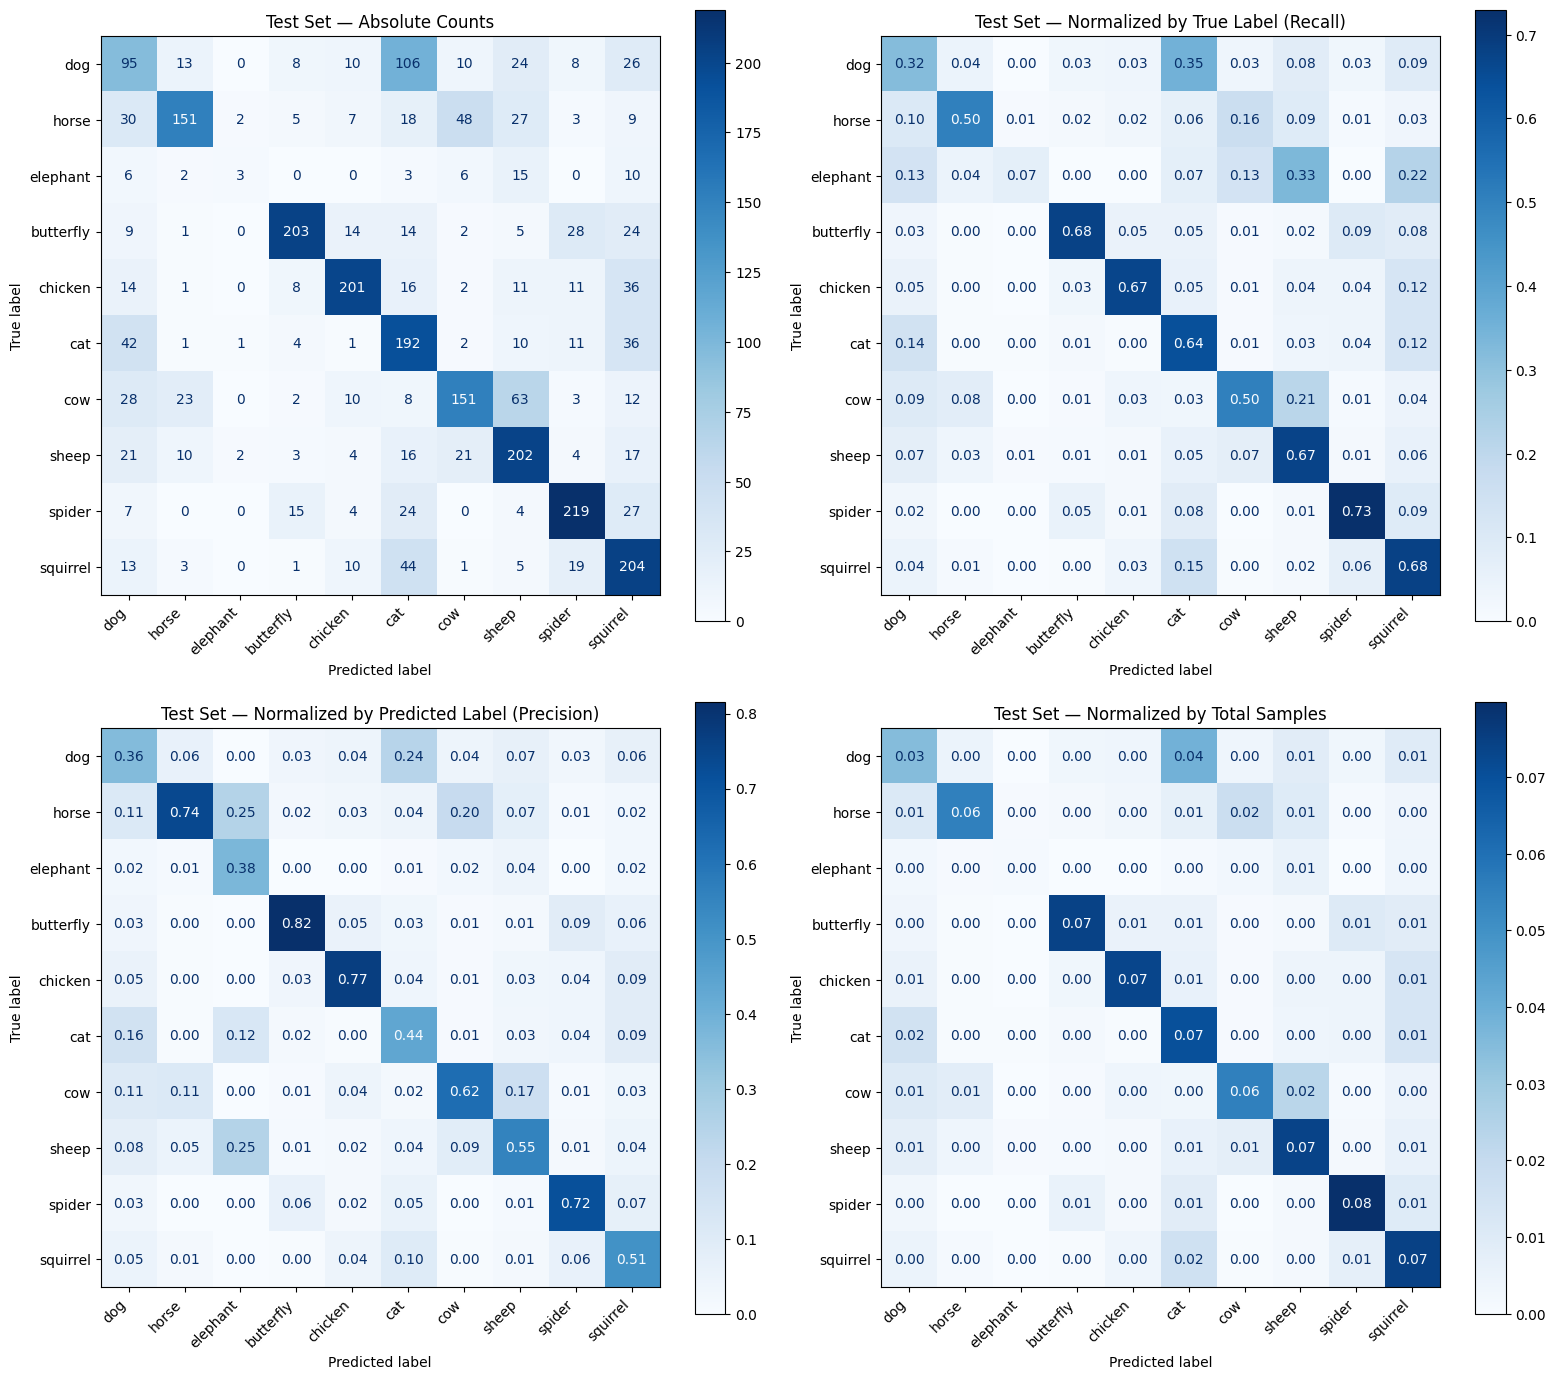

In [14]:
# Detailed test set metrics
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

plot_confusion_matrices(y_test, y_test_pred, class_names, title_prefix="Test Set — ")

In [15]:
print_classification_metrics(y_test, y_test_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.358     0.317     0.336       300
       horse      0.737     0.503     0.598       300
    elephant      0.375     0.067     0.113        45
   butterfly      0.815     0.677     0.740       300
     chicken      0.770     0.670     0.717       300
         cat      0.435     0.640     0.518       300
         cow      0.621     0.503     0.556       300
       sheep      0.552     0.673     0.607       300
      spider      0.716     0.730     0.723       300
    squirrel      0.509     0.680     0.582       300

    accuracy                          0.591      2745
   macro avg      0.589     0.546     0.549      2745
weighted avg      0.609     0.591     0.589      2745



## 12. Final Discussion and Conclusions

### Summary of All Three Architectures

| | Arch. 1 (Underfit) | Arch. 2 (Overfit) | Arch. 3 (Regularized) |
|---|---|---|---|
| Parameters | ~1,700 | ~768,000 | ~768,000 |
| Regularization | None | None | Dropout + L2 + EarlyStopping |
| Training Accuracy | Low (~45%) | Very high (~99%) | Moderate |
| Validation Accuracy | Low (~37%) | Medium (~53%) | Medium |
| Train-Val Gap | Small | Very large (~45%) | Small |
| Validation Loss | High | Diverges | Stable (best) |
| Generalization | Poor (too simple) | Poor (memorizes) | Good |

### Key Takeaways

1. **Model capacity matters:** Architecture 1 was too simple to learn the data (underfitting). Architecture 2 was complex enough to learn but memorized noise (overfitting). The right capacity depends on both model complexity and regularization.

2. **Regularization is essential:** Dropout, L2 regularization, and EarlyStopping are simple but effective techniques to prevent overfitting. They allow us to use a complex model while maintaining good generalization. The key indicator is the **train-val gap**: a well-regularized model has a small gap.

3. **Accuracy vs. Loss:** The overfitted model (Arch. 2) may have comparable or even higher validation accuracy than the regularized model (Arch. 3). However, the **validation loss** of the regularized model is lower and stable (does not diverge), indicating more calibrated predictions.

4. **Class imbalance:** The reduced elephant class (150 samples) consistently showed lower performance across all architectures, especially in recall. Handling class imbalance (e.g., with class weights or data augmentation) would be a logical next step.

5. **Cross-Validation:** The 5-fold CV results provide a robust estimate of the generalization error. The test set accuracy falls within the range predicted by CV, confirming the reliability of our evaluation.

6. **Hyperparameter sensitivity:** The L2 lambda parameter has a strong effect. Too small → overfitting returns. Too large → underfitting. The optimal value (`1e-3`) lies in between and was found through experimentation.